BRITISH AIRWAYS PREDICTION MODEL ON CUSTOMER BOOKING

In [17]:
#I am building a model for prediction:
#import the dataset from files
#call the dataset
import pandas as pd

customer_booking = pd.read_csv('customer_booking.csv', encoding='latin1') #I came across an issue with my dataset resulting in having to use "latin1"
customer_booking.head() #this shows the successful importing of the dataset

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


In [18]:
#now we will clean the dataset to build the model
#check for info of each variable
customer_booking.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

In [19]:

#we will need to encode the catergorical/variables with ojects not numeric values wuthin insdie of them
# Check if the columns to be dummified still exist before applying get_dummies
customer_booking =pd.get_dummies( customer_booking , columns=['trip_type', 'sales_channel', 'flight_day'], drop_first=True)
#convert them from booleans to numeirc
cols = customer_booking.select_dtypes(include=['bool']).columns
customer_booking[cols] = customer_booking[cols].astype(int)

#

# Note: Corrected 'booking_orgin' to 'booking_origin' in the loop
for x in ['route', 'booking_origin']:
  y=customer_booking[x].value_counts(normalize=True)
  customer_booking[x] = customer_booking[x].map(y)



print(customer_booking.shape)
customer_booking

(50000, 20)


,num_passengers,purchase_lead,length_of_stay,flight_hour,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete,trip_type_OneWay,trip_type_RoundTrip,sales_channel_Mobile,flight_day_Mon,flight_day_Sat,flight_day_Sun,flight_day_Thu,flight_day_Tue,flight_day_Wed
0,2,262,19,7,0.00040,0.02148,1,0,0,5.52,0,0,1,0,0,1,0,0,0,0
1,1,112,20,3,0.00040,0.02148,0,0,0,5.52,0,0,1,0,0,1,0,0,0,0
2,2,243,22,17,0.00040,0.02540,1,1,0,5.52,0,0,1,0,0,0,0,0,0,1
3,1,96,31,4,0.00040,0.02148,0,0,1,5.52,0,0,1,0,0,1,0,0,0,0
4,2,68,22,15,0.00040,0.02540,1,0,1,5.52,0,0,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,2,27,6,9,0.00442,0.35744,1,0,1,5.62,0,0,1,0,0,1,0,0,0,0
49996,1,111,6,4,0.00442,0.35744,0,0,0,5.62,0,0,1,0,0,0,1,0,0,0
49997,1,24,6,22,0.00442,0.35744,0,0,1,5.62,0,0,1,0,0,1,0,0,0,0
49998,1,15,6,11,0.00442,0.35744,1,0,1,5.62,0,0,1,0,1,0,0,0,0,0


In [20]:
#check for null values
customer_booking.isnull().sum()

,0
num_passengers,0
purchase_lead,0
length_of_stay,0
flight_hour,0
route,0
booking_origin,0
wants_extra_baggage,0
wants_preferred_seat,0
wants_in_flight_meals,0
flight_duration,0


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
#WE WILL BUILD the model

X= customer_booking.drop('booking_complete', axis=1)
Y= customer_booking['booking_complete']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state= 42, stratify=Y)

Model_British_Airways = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
Model_British_Airways.fit(X_train, Y_train)


RandomForestClassifier(class_weight='balanced', random_state=42)

In [24]:
from sklearn.metrics import classification_report, accuracy_score
#evaluate the model built to see how accurate it is.
y_predic = Model_British_Airways.predict(X_test)


print("Accuracy: ", accuracy_score(Y_test, y_predic))
print(classification_report(Y_test, y_predic))

Accuracy:  0.8531
              precision    recall  f1-score   support

           0       0.86      0.99      0.92      8504
           1       0.56      0.08      0.14      1496

    accuracy                           0.85     10000
   macro avg       0.71      0.54      0.53     10000
weighted avg       0.82      0.85      0.80     10000



<function matplotlib.pyplot.show(close=None, block=None)>

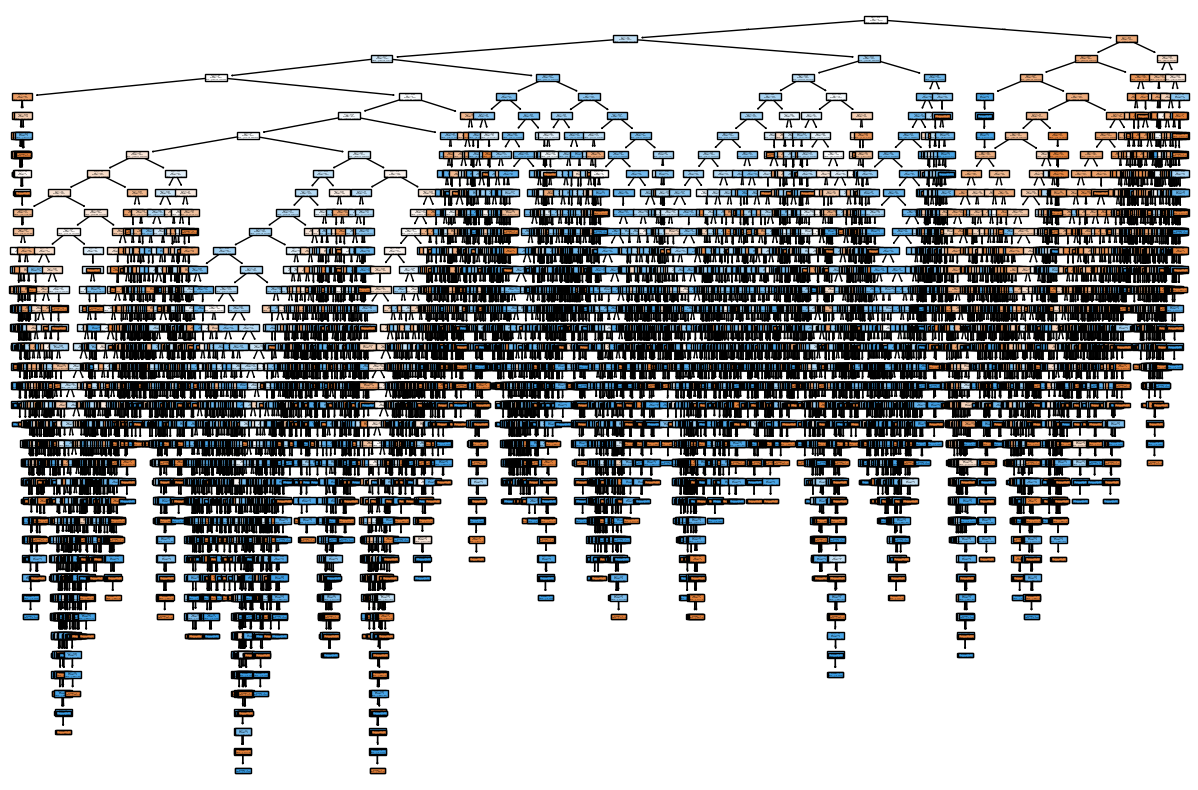

In [25]:
#visualize tree :
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

#we plot the tree our forest
plt.figure(figsize=(15, 10))
plot_tree(Model_British_Airways.estimators_[0], filled=True)
plt.show